In [ ]:
import os
import use_triton_in_paddle; use_triton_in_paddle.make_triton_compatible_with_paddle()

import paddle
paddle.set_device('gpu:2')


### 基本的cuda概念



#### 1. Grid
- **定义**: Grid 是 CUDA 编程中最顶层的线程组织单位。
- **结构**: 由一个或多个 block 组成，可以是一维、二维或三维的。
- **作用**: 用于组织和管理整个计算任务。

#### 2. Block
- **定义**: Block 是 Grid 中的基本执行单元。
- **结构**: 由多个线程组成，可以是一维、二维或三维的。
- **特点**: 同一个 block 内的线程可以共享内存和同步。

#### 3. Warp
- **定义**: Warp 是 CUDA 硬件调度的基本单位。
- **结构**: 通常由 32 个线程组成。
- **特点**: Warp 内的线程执行相同的指令，但可以处理不同的数据。

#### 4. Thread
- **定义**: Thread 是 CUDA 编程中最基本的执行单元。
- **特点**:
  - 每个 thread 都有独立的执行路径。
  - 拥有自己的寄存器、局部内存和程序计数器。
  - 通过线程索引（`threadIdx`）来标识自己在 block 中的位置。
- **作用**: 执行具体的计算任务，是并行计算的最小单位。

#### 总结
- **Grid**: 整个计算任务的线程组织。
- **Block**: Grid 中的基本执行单元。
- **Warp**: 硬件调度的基本单位，通常 32 个线程。
- **Tile**: 数据分割的优化技术，用于提高计算效率。



#### 相互关系
这几个概念之间的关系如下

```shell
+---------------------+
|        Grid         |  (整个计算任务)
|  +-----+  +-----+   |
|  |Block|  |Block|   |  (Grid 由多个 Block 组成)
|  +-----+  +-----+   |
|  +-----+  +-----+   |
|  |Block|  |Block|   |
|  +-----+  +-----+   |
+---------------------+

+---------------------+
|        Block        |  (Block 是 Grid 的基本执行单元)
|  +---+  +---+  +---+|
|  |Thd|  |Thd|  |Thd||  (Block 由多个 Thread 组成) 
|  +---+  +---+  +---+|  **triton对这个粒度以下的内容进行了抽象，用于只需要在block级别写代码就可以**
|  +---+  +---+  +---+|
|  |Thd|  |Thd|  |Thd||
|  +---+  +---+  +---+|
+---------------------+

+---------------------+
|        Thread       |  (Thread 是 Block 的基本执行单元)
|  +---+  +---+  +---+|
|  |   |  |   |  |   ||  (每个 Thread 执行具体的计算任务)
|  +---+  +---+  +---+|
+---------------------+
```

Grid 是最大的组织单位，包含多个 Block。

Block 是 Grid 的组成部分，包含多个 Thread。

Thread 是最小的执行单元，负责具体的计算任务。 

Warp 是 CUDA 硬件调度的基本单位，是硬件层面的概念，由 CUDA 硬件自动管理，同一个 Warp 内的 Thread 执行相同的指令（SIMD 模型），但可以处理不同的数据。同一个Warp内部执行相同的指令，但可以处理不同的数据，不同的Warp需要显式同步

### triton写法和cuda写法区别


#### 1.1 编程模型
- **CUDA**:
  - 基于 **线程层次结构**（Grid、Block、Thread）。
  - 需要显式管理线程索引、内存层次（全局内存、共享内存等）和同步。
- **Triton**:
  - 基于 **块级编程模型**，开发者只需关注如何操作一个块（Tile）的数据。
  - 自动管理线程和内存层次，隐藏了底层细节。

#### 1.2 内存管理
- **CUDA**:
  - 需要显式管理全局内存、共享内存和寄存器。
  - 手动优化内存访问模式（如合并访问）。
- **Triton**:
  - 提供高层次的内存抽象（如 `tl.load` 和 `tl.store`）。
  - 自动优化内存访问，支持高效的共享内存和寄存器使用。


#### 1.3 并行性
- **CUDA**:
  - 需要显式定义线程的并行行为（如 `threadIdx.x`）。
  - 需要手动处理 Warp 级别的并行和分支发散。
- **Triton**:
  - 自动处理并行性，开发者只需定义数据块的计算逻辑。
  - 自动优化 Warp 级别的执行，减少分支发散的影响。

### triton代码编写注意事项



#### 内存访问
使用 `tl.load` 和 `tl.store` 进行内存读写。
```python
x = tl.load(ptr_x + offsets, mask=mask)
tl.store(ptr_y + offsets, y, mask=mask)
```

#### Mask使用
使用掩码来处理边界条件，确保越界访问不会发生

#### 调试
Triton 提供了调试工具（如 `tl.debug`），可以打印中间结果

```python
tl.debug("x =", x)
```

### 以Add为例，如何写一段triton代码？

In [ ]:
# 定义kernel
import triton
import triton.language as tl
import paddle
import use_triton_in_paddle; use_triton_in_paddle.make_triton_compatible_with_paddle() # 添加paddle依赖
paddle.set_device('gpu:0')

@triton.jit
def add_kernel(x_ptr, y_ptr, z_ptr, n, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    z = x + y
    tl.store(z_ptr + offsets, z, mask=mask)

In [ ]:
n = 1024
x = paddle.randn([n], dtype='float32')
y = paddle.randn([n], dtype='float32')
z = paddle.zeros([n], dtype='float32')

In [ ]:
# Triton 使用网格和块来组织并行计算。需要根据数据大小和硬件特性定义合适的网格和块大小
BLOCK_SIZE = 128
grid = lambda meta: (triton.cdiv(n, meta['BLOCK_SIZE']),)

In [ ]:
# 直接调用kernel
add_kernel[grid](x,y,z,n, BLOCK_SIZE=BLOCK_SIZE)

#### 验证结果

In [ ]:
expected = x + y
add_kernel[grid](x,y,z,n, BLOCK_SIZE=BLOCK_SIZE) # 调用kernel
print(paddle.allclose(expected, z))

#### profiliing
Triton 会输出 Kernel 的执行时间、内存带宽等信息。

In [ ]:
out_triton = triton.testing.do_bench(lambda: add_kernel[grid](x,y,z,n, BLOCK_SIZE=BLOCK_SIZE))
out_pp = triton.testing.do_bench(lambda: x+y)
print(f'triton:{out_triton} ms;\tpaddle:{out_pp} ms')

### WINT2量化与反量化

In [1]:
import paddle
import paddle.nn.functional as F

import triton
import triton.language as tl
import use_triton_in_paddle; use_triton_in_paddle.make_triton_compatible_with_paddle()



量化与反量化函数  
ver0.0, 使用朴素absmax rounding

In [2]:

def quantize(W, asymm=False):
    bits = 2
    out_dtype = W.dtype
    W = W.cast('float32')
    if asymm:
        bnt = 2**bits - 1
        w_max =  F.relu(W).max(0,keepdim=True)
        w_min = -F.relu(-W).max(0,keepdim=True)
        w_range = w_max - w_min
        scale = w_range / bnt
        scale = paddle.where(scale == paddle.to_tensor(0, dtype=W.dtype), paddle.to_tensor(1e-8, dtype=W.dtype), scale)
        zp = (-w_min / scale).round().clip(0, bnt)
        qw = (W / scale + zp).round().clip(0, bnt)
        return qw.cast(out_dtype), scale.cast(out_dtype), zp.cast(out_dtype)
    else:
        bnt = 2**(bits-1) - 1
        quant_scale = paddle.max(paddle.abs(W), axis=0,keepdim=True)
        quant_scale = paddle.where(quant_scale == paddle.to_tensor( 0, dtype=W.dtype),paddle.to_tensor(1e-8, dtype=W.dtype),quant_scale)
        
        qw = paddle.clip(paddle.round(W / quant_scale * bnt),-bnt, bnt)
        qw = qw + bnt
        bnt = paddle.ones_like(quant_scale) * bnt
        return qw.cast(out_dtype), (quant_scale/bnt).cast(out_dtype), bnt.cast(out_dtype)

def dequantize(qx, scale, zp=None):
    if zp is None:
        return qx*scale
    else:
        return (qx - zp) * scale

支持group_size的版本

In [3]:
def quantize2(W, asymm=False, group_size=128):
    bits = 2
    
    W = W.T
    row,col = W.shape # [Cout, Cin]
    W = W.reshape((-1,group_size))
    if asymm:
        bnt = 2**bits - 1
        w_max =  F.relu(W).max(-1,keepdim=True)
        w_min = -F.relu(-W).max(-1,keepdim=True)
        w_range = w_max - w_min
        scale = w_range / bnt
        zp = (-w_min / scale).round().clip(0, bnt)
        qw = (W / scale + zp).round().clip(0, bnt)
        
    else:
        bnt = 2**(bits-1) - 1
        quant_scale = paddle.max(paddle.abs(W), axis=-1,keepdim=True)
        quant_scale = paddle.where(quant_scale == paddle.to_tensor( 0, dtype=W.dtype),paddle.to_tensor(1e-8, dtype=W.dtype),quant_scale)
        scale = quant_scale/bnt
        qw = paddle.clip(
                        paddle.round(W.cast("float32") / scale),
                        -bnt, bnt)
        qw = qw + bnt
        zp = paddle.ones_like(quant_scale) * bnt
        
    qw = qw.reshape((row, col)).T.contiguous()
    scale = scale.reshape((row,-1)).T.contiguous()
    zp = zp.reshape((row,-1)).T.contiguous()
    return qw, scale, zp 

def dequantize2(qx, scale, zp):
    qx = qx.T
    row,col = qx.shape[0], qx.shape[1]
    group_size = col//scale.shape[0]
    
    # qx = qx.reshape((-1,group_size,col))
    qx = qx.reshape((-1,group_size))
    scale = scale.T.reshape((-1,1))
    zp = zp.T.reshape((-1,1))
    
    if zp is None:
        out= qx*scale
    else:
        out=(qx - zp) * scale
        
    out = out.reshape((row,col)).T
    return out

In [4]:
W = paddle.randn([12800, 4096]).astype('float32')

W0305 10:42:54.295725 124130 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 8.0, Driver API Version: 12.0, Runtime API Version: 12.1
W0305 10:42:54.296479 124130 gpu_resources.cc:164] device: 0, cuDNN Version: 9.1.
W0305 10:42:54.296491 124130 gpu_resources.cc:196] WARNING: device: 0. The installed Paddle is compiled with CUDA 12.3, but CUDA runtime version in your machine is 12.0, which may cause serious incompatible bug. Please recompile or reinstall Paddle with compatible CUDA version.


原始数据的峰度: -0.08829865333121889


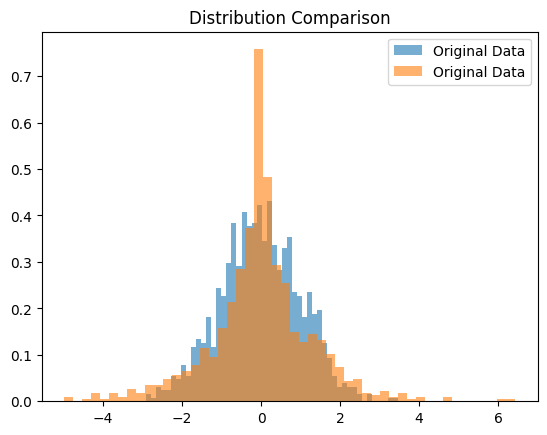

In [5]:
import paddle
from scipy.stats import kurtosis
import matplotlib.pyplot as plt

# 生成标准正态分布的随机数
data = paddle.randn((1000,))  # 均值为 0，标准差为 1

# 计算原始数据的峰度
original_kurtosis = kurtosis(data.numpy())
print(f"原始数据的峰度: {original_kurtosis}")

# 修改峰度：通过调整尾部厚度

# 目标峰度
target_kurtosis = 6  # 例如，目标峰度为 5

# 修改数据


plt.hist(data.numpy(), bins=50, density=True, alpha=0.6, label="Original Data")
plt.hist((data*data.abs().pow(0.5)).numpy(), bins=50, density=True, alpha=0.6, label="Original Data")
plt.legend()
plt.title("Distribution Comparison")
plt.show()

In [6]:
def loss(src,tgt):
    return (src.cast('float32') - tgt.cast('float32')).abs().mean().cast('float32').tolist()

In [ ]:
import timeit
timeit.timeit(lambda: quantize2(W,asymm=True),number=1)

In [ ]:
print('group-wise,非对称')
loss(W,dequantize2(*quantize2(W,asymm=True,group_size=128)))

In [ ]:
print('group-wise,对称')
loss(W,dequantize2(*quantize2(W,asymm=False,group_size=128)))

In [ ]:
print('channel-wise,对称')
loss(W,dequantize(*quantize(W)))

In [ ]:
print('channel-wise,非对称')
loss(W,dequantize(*quantize(W,asymm=True)))

量化方案
ver 0.1, 使用0.7倍rounding

In [ ]:
def quantize3(W, asymm=False, group_size=128):
    bits = 2
    
    W = W.T
    row,col = W.shape # [Cout, Cin]
    W = W.reshape((-1,group_size))
    if asymm:
        bnt = 2**bits - 1
        w_max =  F.relu(W).max(-1,keepdim=True)
        w_min = -F.relu(-W).max(-1,keepdim=True)
        w_range = w_max - w_min
        scale = w_range / bnt
        zp = (-w_min / scale).round().clip(0, bnt)
        qw0 = W / scale
        qw0 = qw0.abs().pow(0.5)*paddle.sign(qw0)
        qw = (qw0.clip(-1,1) + zp).round().clip(0, bnt)
        new_scale = (W).abs().sum(-1,keepdim=True) / (qw-zp).round().abs().sum(-1,keepdim=True)
        scale = new_scale
        
    else:
        bnt = 2**(bits-1) - 1
        quant_scale = paddle.max(paddle.abs(W), axis=-1,keepdim=True)
        # w_max =  F.relu(W).max(-1,keepdim=True)
        # w_min = -F.relu(-W).max(-1,keepdim=True)
        quant_scale = paddle.where(quant_scale == paddle.to_tensor( 0, dtype=W.dtype),paddle.to_tensor(1e-8, dtype=W.dtype),quant_scale)
        scale = quant_scale/bnt
        qw0 = W.cast("float32") / scale
        # qw0 = qw0.abs().pow(0.98) * paddle.sign(qw0)
        qw0 = qw0.abs().pow(0.5)*paddle.sign(qw0)
        qw = paddle.clip(
                        paddle.round(qw0),
                        -bnt, bnt)
        qw = qw + bnt
        zp = paddle.ones_like(quant_scale) * bnt
        
        new_scale = (W).abs().sum(-1,keepdim=True) / (qw-bnt).abs().sum(-1,keepdim=True)
        scale = new_scale
        
    qw = qw.reshape((row, col)).T.contiguous()
    scale = scale.reshape((row,-1)).T.contiguous()
    zp = zp.reshape((row,-1)).T.contiguous()
    return qw, scale, zp 

def dequantize3(qx, scale, zp):
    qx = qx.T
    row,col = qx.shape[0], qx.shape[1]
    group_size = col//scale.shape[0]
    
    # qx = qx.reshape((-1,group_size,col))
    qx = qx.reshape((-1,group_size))
    scale = scale.T.reshape((-1,1))
    zp = zp.T.reshape((-1,1))
    
    if zp is None:
        out= qx*scale
    else:
        out=(qx - zp) * scale
        
    out = out.reshape((row,col)).T
    return out

In [ ]:
inp = paddle.randn((512,12800))

In [ ]:
print('group-wise,非对称')
loss(inp @ W,inp @ dequantize3(*quantize3(W,asymm=False,group_size=128)))

In [ ]:
print('group-wise,非对称')
loss(inp @ W,inp @ dequantize2(*quantize2(W,asymm=False,group_size=128)))

In [ ]:
# W2 = W

W = W2.abs().pow(2) * W.sign()

In [ ]:
def Kurtosis(x):
    mean = paddle.mean(x)
    
    # 计算方差（二阶中心矩）
    variance = paddle.mean((x - mean) ** 2)
    
    # 计算四阶中心矩
    m4 = paddle.mean((x - mean) ** 4)
    
    # 计算峰度
    kurt = m4 / (variance ** 2)
    
    # 如果 excess=True，返回修正的峰度（减去3）
    # if excess:
    kurt -= 3
    
    return kurt

In [ ]:
K = Kurtosis(W)
K = (K+1)**(1/4)

In [ ]:
bnt=1
W_tmp = W.reshape((-1, 128))
quant_scale = paddle.max(paddle.abs(W_tmp), axis=-1,keepdim=True)
quant_scale = paddle.where(quant_scale == paddle.to_tensor( 0, dtype=W.dtype),paddle.to_tensor(1e-8, dtype=W.dtype),quant_scale)
scale = quant_scale/bnt

# qw0 = qw0.abs().pow(0.98) * paddle.sign(qw0)


In [ ]:
qw0 = W_tmp.cast("float32") / scale
qw0 = qw0.abs().pow(1/2)*paddle.sign(qw0)
qw = paddle.clip(
                paddle.round(qw0),
                -bnt, bnt)
new_scale = (W_tmp).abs().sum(-1,keepdim=True) * (1 / (qw).abs().sum(-1,keepdim=True))#.pow(8)
qdqw = qw * new_scale

error = loss(qdqw, W_tmp)

In [ ]:
plt.hist(qw0.flatten().cast('float32').numpy(), bins=50,label=f'weight before round')
plt.hist(qw.flatten().cast('float32').numpy(), bins=50,label=f'weight after round,loss(FP vs. qdqw):{error:.4f}')
plt.legend()
plt.show()

In [ ]:
qw0 = W_tmp.cast("float32") / scale
qw = paddle.clip(
                paddle.round(qw0),
                -bnt, bnt)
qdqw = qw * scale

error = loss(qdqw, W_tmp)

In [ ]:
plt.hist(qw0.flatten().cast('float32').numpy(), bins=50,label=f'weight before round')
plt.hist(qw.flatten().cast('float32').numpy(), bins=50,label=f'weight after round,loss(FP vs. qdqw):{error:.4f}')
plt.legend()
plt.show()

### PACK方案
**ver 0.0**: 按照INT2存储三值  
特点：只有-1，0，1三种取值 
计算过程：  
1. INT32->UINT8: x' = x + zp
2. 4xUINT8->1xUINT8: 按照row major方式进行pack

In [7]:
def pack_to_int2(src):
    src_bitwidth=8
    if src.dtype != paddle.uint8:
        src = src.cast('uint8')

    row,col = src.shape
    pack_num = src_bitwidth // 2 # there will be pack_num UINT2 value in one UINT8 value
    
    int_tgt = paddle.zeros((row, col// pack_num)).astype('uint8')
    for pack in range(0, col, pack_num):
        for i in range(pack_num):
            int_tgt[:, pack // pack_num] += src[:,pack + i] << (i*2)
    return int_tgt

def unpack_int2_to_uint8(src):
    pack_num = 4 # 4 UINT2 value in one UINT8 value
    row,col = src.shape
    int_tgt = paddle.zeros((row,col* pack_num)).astype('uint8')
    for pack in range(0, col):
        for i in range(pack_num):
            int_tgt[:,pack * pack_num + i] = src[:,pack] >> (i*2) & paddle.to_tensor(0x3).cast('uint8')
    return int_tgt
        
    
    

In [8]:
def pack_to_int2(src):
    src_bitwidth=8
    if src.dtype != paddle.uint8:
        src = src.cast('uint8')

    row,col = src.shape
    pack_num = src_bitwidth // 2 # there will be pack_num UINT2 value in one UINT8 value
    
    int_tgt = paddle.zeros((row, col// pack_num)).astype('uint8')
    shift_bits = (paddle.arange(0,pack_num)*2).cast('uint8')
    
    src = src.reshape((row, col//pack_num, pack_num))
    src = src << shift_bits
    int_tgt = src.sum(axis=-1)
    return int_tgt

def unpack_int2_to_uint8(src):
    pack_num = 4 # 4 UINT2 value in one UINT8 value
    row,col = src.shape
    # int_tgt = paddle.zeros((row,col* pack_num)).astype('uint8')
    int_tgt = src.reshape((row,col,1)).expand((row,col,pack_num))
    shift_bits = (paddle.arange(0,pack_num)*2).cast('uint8')
    int_tgt = int_tgt >> shift_bits & paddle.to_tensor(0x3).cast('uint8')
    int_tgt = int_tgt.reshape((row,col*pack_num))
    # for pack in range(0, col):
    #     for i in range(pack_num):
    #         int_tgt[:,pack * pack_num + i] = src[:,pack] >> (i*2) & paddle.to_tensor(0x3).cast('uint8')
    return int_tgt

In [9]:
def pack_to_int2_v2(src):
    src_bitwidth=16
    if src.dtype != paddle.int16:
        src = src.cast('int16')

    row,col = src.shape
    pack_num = src_bitwidth // 2 # there will be pack_num UINT2 value in one UINT8 value
    
    int_tgt = paddle.zeros((row, col// pack_num)).astype('int16')
    shift_bits = (paddle.arange(0,pack_num)*2).cast('int16')
    
    src = src.reshape((row, col//pack_num, pack_num))
    src = src << shift_bits
    int_tgt = src.sum(axis=-1)
    return int_tgt

def unpack_int2_to_int16(src):
    pack_num = 8 # 8 UINT2 value in one INT16 value
    row,col = src.shape
    # int_tgt = paddle.zeros((row,col* pack_num)).astype('uint8')
    int_tgt = src.reshape((row,col,1)).expand((row,col,pack_num))
    shift_bits = (paddle.arange(0,pack_num)*2).cast('int16')
    int_tgt = int_tgt >> shift_bits & paddle.to_tensor(0x3).cast('int16')
    int_tgt = int_tgt.reshape((row,col*pack_num))
    # for pack in range(0, col):
    #     for i in range(pack_num):
    #         int_tgt[:,pack * pack_num + i] = src[:,pack] >> (i*2) & paddle.to_tensor(0x3).cast('uint8')
    return int_tgt

In [10]:
Qw,scale,zp = quantize2(W,asymm=True)

In [11]:
Qw.shape,scale.shape,zp.shape

([12800, 4096], [100, 4096], [100, 4096])

In [12]:
# 测试latency
import timeit

In [13]:
pack_zp = pack_to_int2(zp.cast('uint8'))
pack_zp.shape

[100, 1024]

In [14]:
timeit.timeit(lambda: pack_to_int2(zp.cast('uint8')),number=1)

0.0010554869659245014

In [15]:
unpack_zp = unpack_int2_to_uint8(pack_zp)
unpack_zp.shape

[100, 4096]

In [16]:
timeit.timeit(lambda: unpack_int2_to_uint8(pack_zp),number=1)

0.0011934442445635796

In [17]:
loss(zp,unpack_zp.cast('float32'))

0.0

In [18]:
pack_zp2 = pack_to_int2_v2(zp.cast('int16'))
pack_zp2.shape,pack_zp2.dtype

([100, 512], <DataType.INT16: 5>)

In [19]:

unpack_zp2 = unpack_int2_to_int16(pack_zp2)

In [20]:
unpack_zp2.shape, unpack_zp2.dtype

([100, 4096], <DataType.INT16: 5>)

In [21]:
unpack_zp2

Tensor(shape=[100, 4096], dtype=int16, place=Place(gpu:0), stop_gradient=True,
       [[1, 1, 2, ..., 2, 2, 1],
        [2, 2, 1, ..., 1, 2, 2],
        [2, 1, 1, ..., 2, 2, 1],
        ...,
        [1, 1, 2, ..., 1, 2, 1],
        [2, 2, 1, ..., 2, 2, 2],
        [1, 1, 2, ..., 1, 1, 1]])

In [22]:
zp

Tensor(shape=[100, 4096], dtype=float32, place=Place(gpu:0), stop_gradient=True,
       [[1., 1., 2., ..., 2., 2., 1.],
        [2., 2., 1., ..., 1., 2., 2.],
        [2., 1., 1., ..., 2., 2., 1.],
        ...,
        [1., 1., 2., ..., 1., 2., 1.],
        [2., 2., 1., ..., 2., 2., 2.],
        [1., 1., 2., ..., 1., 1., 1.]])

In [23]:
loss(unpack_zp2,zp)

0.0

### WINT2 matmul设计
ref: [lightllm INT4设计](https://github.com/ModelTC/lightllm/blob/00e4de7439559ea1797de2e5e4d913a971879b2b/lightllm/common/basemodel/triton_kernel/dequantize_gemm_int4.py#L225)

In [24]:
def get_wint2_kernel_config():

    configs = [
    triton.Config({'BLOCK_SIZE_M':256, 'BLOCK_SIZE_N':32, 'BLOCK_SIZE_K':64, 'SPLIT_K':2, 'GROUP_SIZE_M':8,}, 
                             num_warps=4, num_stages=1)
    ]
    return configs

UINT8 matmul kernel

In [52]:

@triton.autotune(
    configs=get_wint2_kernel_config(),
    key=['M', 'N', 'K'],
    reset_to_zero=['c_ptr'],
)
@triton.jit
def matmul_kernel(
    a_ptr, b_ptr, c_ptr,
    bs_ptr, bzp_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    stride_bsk, stride_bsn,
    stride_bzpk, stride_bzpn,
    group_size,
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr, SPLIT_K: tl.constexpr
):
    """
    assert K % (BLOCK_SIZE_K * SPLIT_K) == 0
    """
    pid = tl.program_id(axis=0)
    pid_sp_k = tl.program_id(axis=1)
    # num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    # num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    # num_pid_k = tl.cdiv(K, BLOCK_SIZE_K)
    
    # num_pid_in_group = GROUP_SIZE_M * num_pid_n
    # group_id = pid // num_pid_in_group
    # first_pid_m = group_id * GROUP_SIZE_M
    
    # group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    # pid_m = first_pid_m + (pid % group_size_m)
    # pid_n = (pid % num_pid_in_group) // group_size_m   
    pid_m, pid_n = swizzle_tile(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M)
    
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offs_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offs_k = pid_sp_k * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
    
    offs_bk = pid_sp_k * (BLOCK_SIZE_K // 4) + tl.arange(0, BLOCK_SIZE_K // 4)
    offs_bzn = (pid_n * BLOCK_SIZE_N // 4 + tl.arange(0, BLOCK_SIZE_N // 4)) % (N // 4)
    
    # tl.static_print(BLOCK_SIZE_K//group_size)
    offs_bzk = pid_sp_k * BLOCK_SIZE_K // group_size + tl.arange(0, 1)
    # [BLOCK_M, BLOCK_K]
    a_ptrs = a_ptr + offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak
    # [BLOCK_K, BLOCK_N] but repeated 4 times in N 
    # b_ptrs = b_ptr + (offs_k[:, None] // 4) * stride_bk + offs_bn[None, :] * stride_bn
    b_ptrs = b_ptr + offs_bk[:, None] * stride_bk + offs_bn[None, :] * stride_bn
    
    # We accumulate into a `[BLOCK_SIZE_M, BLOCK_SIZE_N]` block
    # of fp32 values for higher accuracy.
    # `accumulator` will be converted back to fp16 after the loop.
    
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    
    # magic_number = 0x00006400
    # magic_number = magic_number.to(tl.uint16)
    
    
    
    for k in tl.range(tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):#range(0, tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):
        # Load the next block of A and B.
        # [BLOCK_K, BLOCK_N] but repeated group_size times in K
        # bs_ptrs = bs_ptr + offs_bn[None, :] * stride_bsn
        bs_ptrs = bs_ptr + ((offs_bzk[:, None] + k * BLOCK_SIZE_K * SPLIT_K // group_size)) * stride_bsk \
            + offs_bn[None, :] * stride_bsn
        # [BLOCK_K, BLOCK_N] but repeated in K and N
        # TODO reduce the number of load zp
        bzp_ptrs = bzp_ptr + ((offs_bzk[:, None] + k * BLOCK_SIZE_K * SPLIT_K // group_size)) * stride_bzpk \
            + offs_bzn[None, :] * stride_bzpn
        # bzp_ptrs = bzp_ptr + ((offs_k[:, None] + k * BLOCK_SIZE_K * SPLIT_K) // group_size) * stride_bzpk \
        #     + offs_bzn[None, :] * stride_bzpn
        # bzp_ptrs = bzp_ptr + ((offs_k[:, None] + k * BLOCK_SIZE_K * SPLIT_K) // group_size) * stride_bzpk \
        #     + (offs_bn[None, :] // 4) * stride_bzpn
        b_shift_bits = (offs_k[:, None] % 4) * 2
        bzp_shift_bits = (offs_bn[None, :] % 4) * 2
        
                                                                   
        a = tl.load(a_ptrs)
        b = tl.load(b_ptrs)
        
        # brow,bcol = b.shape[0],b.shape[1]
        # print(b.shape)
        # tl.static_print(b.shape)
        b = b.permute(1,0)
        b = b.expand_dims(axis=-1)
        b = b.broadcast_to(BLOCK_SIZE_N,BLOCK_SIZE_K//4,4).reshape(BLOCK_SIZE_N,BLOCK_SIZE_K)
        b = b.permute(1,0)
        # tl.static_print(b.shape)
        bs = tl.load(bs_ptrs)
        bzp = tl.load(bzp_ptrs)
        bzp = bzp.permute(1,0)
        bzp = bzp.broadcast_to(BLOCK_SIZE_N//4,BLOCK_SIZE_K)#.reshape(BLOCK_SIZE_N//4,BLOCK_SIZE_K)
        bzp = bzp.permute(1,0)
        
        bzp = bzp.expand_dims(axis=-1)
        bzp = bzp.broadcast_to(BLOCK_SIZE_K,BLOCK_SIZE_N//4,4)
        bzp = bzp.reshape(BLOCK_SIZE_K,BLOCK_SIZE_N)
        
        int_b = (b >> b_shift_bits) & 0x3
        int_bzp = (bzp >> bzp_shift_bits) & 0x3
        
        bs = bs.broadcast_to(BLOCK_SIZE_K,BLOCK_SIZE_N)
        
        b = ((int_b - int_bzp) * bs) #.to(a.dtype)
        
        accumulator += tl.dot(a, b.to(a.dtype))
        # accumulator += tl.dot(a, b)
        
        # Advance the ptrs to the next K block.
        a_ptrs += BLOCK_SIZE_K * SPLIT_K * stride_ak
        b_ptrs += (BLOCK_SIZE_K * SPLIT_K * stride_bk // 4)  # assert BLOCK_SIZE_K % 4 == 0
        
    # You can fuse arbitrary activation functions here
    # while the accumulator is still in FP32!
    c = accumulator.to(c_ptr.dtype.element_ty)


    # -----------------------------------------------------------
    # Write back the block of the output matrix C with masks.
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    if SPLIT_K == 1:
        tl.store(c_ptrs, c, mask=c_mask)
    else:
        tl.atomic_add(c_ptrs, c, mask=c_mask)
 

def matmul_dequantize_int2(x, qw, scales, zp, group_size=None,output=None):
    assert x.is_contiguous(), "A must be contiguous"
    assert qw.is_contiguous(), "B must be contiguous"
    
    M,K = x.shape
    N = qw.shape[1]
    
    if group_size is None:
        group_size = K // scales.shape[0]

    if output is None:
        output = paddle.zeros([M,N], dtype=x.dtype)
        
    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']),
        META['SPLIT_K'],
    )

    x_stride0,x_stride1 = x.shape[1], 1
    qw_stride0,qw_stride1 = qw.shape[1], 1
    scales_stride0,scales_stride1 = scales.shape[1], 1
    zp_stride0, zp_stride1 = zp.shape[1], 1
    output_stride0,output_stride1 = output.shape[1], 1
    matmul_kernel[grid](
        x, qw, output,
        scales, zp,
        M, N, K,
        x_stride0, x_stride1,
        qw_stride0, qw_stride1,
        output_stride0, output_stride1,
        scales_stride0, scales_stride1,
        zp_stride0, zp_stride1,
        group_size,

    )
    
    return output   

INTX matmul kernel

In [44]:
import custom_autotune

@triton.jit
def swizzle_tile(pid, M, N, BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, GROUP_SIZE_M: tl.constexpr):
    grid_m     = tl.cdiv(M, BLOCK_SIZE_M)
    grid_n     = tl.cdiv(N, BLOCK_SIZE_N)
    width      = GROUP_SIZE_M * grid_n
    group_id   = pid // width
    group_size = tl.minimum(grid_m - group_id * GROUP_SIZE_M, GROUP_SIZE_M)
    pid_m      = group_id * GROUP_SIZE_M + (pid % group_size)
    pid_n      = (pid % width) // group_size
    return pid_m, pid_n


@triton.jit
def vetorize_load(offset, block_size):
    return tl.max_contiguous(tl.multiple_of(offset, block_size), block_size) 

def init_to_zero(name):
    return lambda nargs: nargs[name].zero_()

def get_wint2_kernel_config():
    configs = []
    for num_stages in [1,2,3,4]:
        for block_m in [64,128, 256]:
            for block_n in [64,128,256]:#, 256, 512]:
                for block_k in [32,64,128]:#, 256, 512]:
                    for split_k in [1,2,4]:#, 2, 4, 8]:
                        num_warps = 4
                        if block_m * block_n >= 128 * 256:
                            num_warps = 8
                        configs.append(
                            triton.Config(
                            {
                                "SPLIT_K": split_k,
                                "BLOCK_SIZE_M": block_m,
                                "BLOCK_SIZE_N": block_n,
                                "BLOCK_SIZE_K": block_k,
                                "GROUP_SIZE_M": 8,
                                "num_stages": num_stages,
                                "num_warps": num_warps,
                            }
                            )
                        )
    return configs

@triton.jit
def linear_tile(pid, M, N, BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, GROUP_SIZE_M: tl.constexpr):
    pid_m = pid // tl.cdiv(N, BLOCK_SIZE_N)
    pid_n = pid % tl.cdiv(N, BLOCK_SIZE_N)
    return pid_m, pid_n


@custom_autotune.autotune(
        # configs=[
        #     triton.Config({"BLOCK_SIZE_M": 16, "BLOCK_SIZE_N": 16, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=1,num_warps=4),
        #     triton.Config({"BLOCK_SIZE_M": 32, "BLOCK_SIZE_N": 32, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=1,num_warps=4),
        #     triton.Config({"BLOCK_SIZE_M": 32, "BLOCK_SIZE_N": 32, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=4,num_warps=4),
        #     triton.Config({"BLOCK_SIZE_M": 128, "BLOCK_SIZE_N": 128, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=4,num_warps=4),
        #     triton.Config({"BLOCK_SIZE_M": 64, "BLOCK_SIZE_N": 128, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=4,num_warps=4),
        #     triton.Config({"BLOCK_SIZE_M": 128, "BLOCK_SIZE_N": 32, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=4,num_warps=4),
        #     triton.Config({"BLOCK_SIZE_M": 64, "BLOCK_SIZE_N": 64, "BLOCK_SIZE_K": 32, "GROUP_SIZE_M": 8},num_stages=4,num_warps=4),
        # ],
        configs=get_wint2_kernel_config(),
        key=["M", "N", "K"],
        nearest_power_of_two=True,
        prune_configs_by={
            "early_config_prune": custom_autotune.kernel_config_pruner,
            "perf_model": None,
            "top_k": None,
        },
    )
@triton.jit
def matmul_kernel2(
    a_ptr, b_ptr, c_ptr,
    bs_ptr, bzp_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    stride_bsk, stride_bsn,
    stride_bzpk, stride_bzpn,
    group_size,
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr, SPLIT_K: tl.constexpr=1,pack_num: tl.constexpr=4
):
    """
    assert K % (BLOCK_SIZE_K * SPLIT_K) == 0
    """
    pid = tl.program_id(axis=0)
    pid_sp_k = tl.program_id(1)
    
    
    #Offsets

    # pid_m, pid_n = swizzle_tile(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M)
    pid_m, pid_n = linear_tile(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M)
    
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offs_am = vetorize_load(offs_am, BLOCK_SIZE_M)
    
    offs_bn = (pid_n * BLOCK_SIZE_N // pack_num + tl.arange(0, BLOCK_SIZE_N // pack_num)) % (N // pack_num)
    offs_bn = vetorize_load(offs_bn, BLOCK_SIZE_N // pack_num)
    
    offs_bsn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N )) % N
    offs_bsn = vetorize_load(offs_bsn, BLOCK_SIZE_N)
    
    offs_k = pid_sp_k * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
    # offs_k = vetorize_load(offs_k, BLOCK_SIZE_K)
    
    offs_bzn = (pid_n * BLOCK_SIZE_N // pack_num + tl.arange(0, BLOCK_SIZE_N // pack_num)) % (N // pack_num)
    offs_bzn = vetorize_load(offs_bzn, BLOCK_SIZE_N // pack_num)
    
    offs_bzk = pid_sp_k * BLOCK_SIZE_K // group_size + tl.arange(0, 1)
    # offs_bzk = vetorize_load(offs_bzk, BLOCK_SIZE_K // group_size)
    
    a_ptrs = a_ptr + offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak
    b_ptrs = b_ptr + offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn
    
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    
    reverse_awq_order_tensor = ((tl.arange(0, 2) * pack_num // 2)[None, :] +
                                    tl.arange(0, pack_num // 2)[:, None]).reshape(pack_num)
    shifts = reverse_awq_order_tensor * 2
    bit_shifts = tl.broadcast_to(shifts[None, :],
                             (BLOCK_SIZE_K * (BLOCK_SIZE_N // pack_num), pack_num))
    bit_shifts = bit_shifts.reshape(BLOCK_SIZE_K, BLOCK_SIZE_N)
    
    for k in tl.range(tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):#range(0, tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):

        bs_ptrs = bs_ptr + ((offs_bzk[:, None] + k * BLOCK_SIZE_K * SPLIT_K // group_size)) * stride_bsk \
            + offs_bsn[None, :] * stride_bsn
        bzp_ptrs = bzp_ptr + ((offs_bzk[:, None] + k * BLOCK_SIZE_K * SPLIT_K // group_size)) * stride_bzpk \
            + offs_bzn[None, :] * stride_bzpn
                     
        b = tl.load(b_ptrs)
        

        b = tl.interleave(b,b)
        b = tl.interleave(b,b)
        # b = tl.interleave(b,b)
        # b = tl.interleave(b,b)


        bs = tl.load(bs_ptrs)
        bs = bs.broadcast_to(BLOCK_SIZE_K,BLOCK_SIZE_N)
        
        bzp = tl.load(bzp_ptrs)
        
        bzp = tl.interleave(bzp,bzp)
        bzp = tl.interleave(bzp,bzp)
        # bzp = tl.interleave(bzp,bzp)
        # bzp = tl.interleave(bzp,bzp)
        
        bzp = bzp.broadcast_to(BLOCK_SIZE_K,BLOCK_SIZE_N)
        
        int_b = (b >> bit_shifts) & 0x3
        int_bzp = (bzp >> bit_shifts) & 0x3
        
        b = ((int_b - int_bzp) * bs) #.to(a.dtype)

        a = tl.load(a_ptrs)
        accumulator += tl.dot(a, b.to(a.dtype))
        # tl.static_print(accumulator.shape)
        

        a_ptrs += BLOCK_SIZE_K * SPLIT_K * stride_ak
        b_ptrs += BLOCK_SIZE_K * SPLIT_K * N // pack_num # assert BLOCK_SIZE_K % 4 == 0
        
    # You can fuse arbitrary activation functions here
    # while the accumulator is still in FP32!
    c = accumulator.to(c_ptr.dtype.element_ty)


    # -----------------------------------------------------------
    # Write back the block of the output matrix C with masks.
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    if SPLIT_K == 1:
        tl.store(c_ptrs, c, mask=c_mask)
    else:
        tl.atomic_add(c_ptrs, c, mask=c_mask)
 

def matmul_dequantize_int2_v2(x, qw, scales, zp, group_size=None,output=None):
    assert x.is_contiguous(), "A must be contiguous"
    assert qw.is_contiguous(), "B must be contiguous"
    
    M,K = x.shape
    N = scales.shape[1]
    
    if group_size is None:
        group_size = K // scales.shape[0]

    if output is None:
        output = paddle.zeros([M,N], dtype=x.dtype)
        
    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']),
        META['SPLIT_K'],
    )

    x_stride0,x_stride1 = x.shape[1], 1
    qw_stride0,qw_stride1 = qw.shape[1], 1
    scales_stride0,scales_stride1 = scales.shape[1], 1
    zp_stride0, zp_stride1 = zp.shape[1], 1
    output_stride0,output_stride1 = output.shape[1], 1
    matmul_kernel2[grid](
        x, qw, output,
        scales, zp,
        M, N, K,
        x_stride0, x_stride1,
        qw_stride0, qw_stride1,
        output_stride0, output_stride1,
        scales_stride0, scales_stride1,
        zp_stride0, zp_stride1,
        group_size,
        # BLOCK_SIZE_M=128, BLOCK_SIZE_N=32, BLOCK_SIZE_K=64,
        # GROUP_SIZE_M=8, SPLIT_K=1
    )
    
    return output   

测试wint2误差和时延

In [45]:
def interleave_16(Q, n_bits=2):
    # Interleave column dim (for the dequantize code) and pack it to int32
    perm = paddle.to_tensor([0, 2, 4, 6, 1, 3, 5, 7])
    row, col = Q.shape[0], Q.shape[1]
    Q = Q.reshape((-1,len(perm)))[:,perm]
    Q = Q.reshape((-1, col)).contiguous()
    return Q

def reverse_interleave_16(t, n_bits=2):
    bits = n_bits
    bnt = 2**bits - 1

    REVERSE_ORDER = [0, 4, 1, 5, 2, 6, 3, 7]

    row,col = t.shape[0], t.shape[1]
    reverse_order_tensor = paddle.arange(
        col
    ).cast('int32')
    reverse_order_tensor = reverse_order_tensor.view((-1, 16 // bits))
    reverse_order_tensor = reverse_order_tensor[:, REVERSE_ORDER]
    reverse_order_tensor = reverse_order_tensor.reshape((1,col))
    t = t[:, reverse_order_tensor]
    return t

In [46]:
def interleave(Q, n_bits):
    # Interleave column dim (for the dequantize code) and pack it to int32
    if n_bits == 4:
        perm = paddle.to_tensor([0, 2, 4, 6, 1, 3, 5, 7])
    elif n_bits == 2:
        perm = paddle.to_tensor([0,2,4,6,8,10,12,14,
                                 1,3,5,7,9,11,13,15])
    else:
        assert False, "n_bits must be 2 or 4"
        
    row, col = Q.shape[0], Q.shape[1]
    
    Q = Q.reshape((-1,len(perm)))[:,perm]
    Q = Q.reshape((-1, col)).contiguous()
    
    return Q

def reverse_interleave(t, n_bits=2):
    bits = n_bits
    bnt = 2**bits - 1
    if n_bits == 4:
        REVERSE_ORDER = [0, 4, 1, 5, 2, 6, 3, 7]
    elif n_bits == 2:
        REVERSE_ORDER = [0, 8, 1, 9, 2, 10, 3, 11,
                         4, 12, 5, 13, 6, 14, 7, 15]
    row,col = t.shape[0], t.shape[1]
    reverse_order_tensor = paddle.arange(
        col
    ).cast('int32')
    reverse_order_tensor = reverse_order_tensor.view((-1, 32 // bits))
    reverse_order_tensor = reverse_order_tensor[:, REVERSE_ORDER]
    reverse_order_tensor = reverse_order_tensor.reshape((1,col))
    t = t[:, reverse_order_tensor]
    return t

def pack_col(src, tgt_bit=2):
    src_bitwidth=8
    bnt = 2**tgt_bit - 1
    if src.dtype != paddle.int8:
        src = src.cast('int8')

    row,col = src.shape
    pack_num = src_bitwidth // tgt_bit # there will be pack_num UINT2 value in one UINT8 value
    
    int_tgt = paddle.zeros((row, col// pack_num)).astype('int8')
    shift_bits = (paddle.arange(0,pack_num)*tgt_bit).cast('int8')
    
    src = src.reshape((row, col//pack_num, pack_num))
    src = src << shift_bits
    int_tgt = src.sum(axis=-1).cast('int8')
    return int_tgt

def unpack_col(src, tgt_bit=2):
    pack_num = 8 // tgt_bit # 4 UINT2 value in one UINT8 value
    bnt = 2**tgt_bit - 1
    row,col = src.shape
    # int_tgt = paddle.zeros((row,col* pack_num)).astype('uint8')
    int_tgt = src.reshape((row,col,1)).expand((row,col,pack_num))
    shift_bits = (paddle.arange(0,pack_num)*tgt_bit).cast('int8')
    
    int_tgt = int_tgt >> shift_bits & paddle.to_tensor(bnt).cast('int8')
    int_tgt = int_tgt.reshape((row,col*pack_num))
    # for pack in range(0, col):
    #     for i in range(pack_num):
    #         int_tgt[:,pack * pack_num + i] = src[:,pack] >> (i*2) & paddle.to_tensor(0x3).cast('uint8')
    return int_tgt.cast('float16')
    

In [47]:
def test_latency(inp,w, dtype,asymm):
    
    inp = inp.astype(dtype)
    w = w.astype(dtype)
    
    Qw,scale,zp = quantize2(w, asymm=asymm)
    
    # pack_w = pack_col(interleave_16(Qw))
    # pack_zp = pack_col(interleave_16(zp))
    pack_w = pack_col(Qw)
    pack_zp = pack_col(zp)
    pack_w = pack_w.contiguous()
    pack_zp = pack_zp.contiguous()
    
    matmul_dequantize_int2_v2(inp, pack_w, scale, pack_zp)
    out_triton = triton.testing.do_bench(lambda: matmul_dequantize_int2_v2(inp, pack_w, scale, pack_zp))
    out_dequant_depack = triton.testing.do_bench(lambda: inp @ dequantize2(unpack_col(pack_w).cast(w.dtype), scale, unpack_col(pack_zp).cast(w.dtype)))
    print(f'triton:{out_triton} ms;\tpaddle unpack:{out_dequant_depack} ms')
    
    
    

In [38]:
test_config = {
    'dtype': ['float16'],
    'asymm': [True,False],
}

inp,w = paddle.randn([2048,8192]),paddle.randn([8192,4096])
for dtype in test_config['dtype']:
    for asymm in test_config['asymm']:
        print(f'dtype:{dtype},asymm:{asymm}')
        loss = test_latency(inp,w,dtype,asymm)

dtype:float16,asymm:True
triton:2.591203451156616 ms;	paddle unpack:1.729304313659668 ms
dtype:float16,asymm:False
triton:2.5822718143463135 ms;	paddle unpack:1.7155412435531616 ms


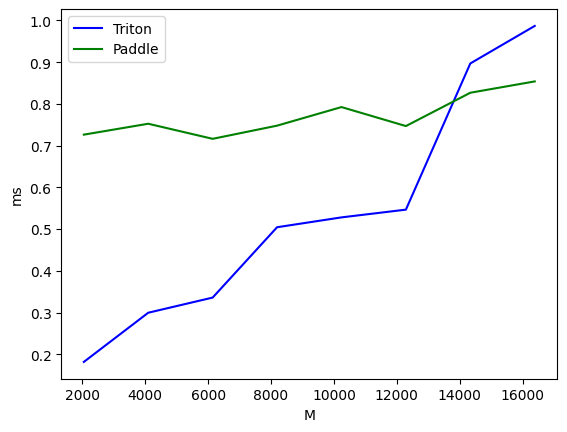

wint2:
         M    Triton    Paddle
0   2048.0  0.181682  0.726254
1   4096.0  0.299544  0.752382
2   6144.0  0.335851  0.716243
3   8192.0  0.504403  0.747800
4  10240.0  0.528012  0.792347
5  12288.0  0.546565  0.746828
6  14336.0  0.896837  0.826677
7  16384.0  0.986767  0.853800


In [53]:

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['M'],  # argument names to use as an x-axis for the plot
        x_vals=[2048 * i for i in range(1, 8+1)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'paddle'],  # possible values for `line_arg``
        line_names=[
            "Triton",
            "Paddle",
        ],  # label name for the lines
        styles=[('blue', '-'), ('green', '-')],  # line styles
        ylabel="ms",  # label name for the y-axis
        plot_name="wint2",  # name for the plot. Used also as a file name for saving the plot.
        args={'N':256, 'K':7168, 'dtype': 'float16', 'asymm': True},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(provider, M, N, K, dtype,asymm):

    with paddle.no_grad():
        inp,w = paddle.randn([M,K]),paddle.randn([K,N])
        inp = inp.astype(dtype)
        w = w.astype(dtype)
        Qw,scale,zp = quantize2(w, asymm=asymm)
        
        # pack_w = pack_col(interleave_16(Qw))
        # pack_zp = pack_col(interleave_16(zp))
        # pack_w = pack_col(Qw)
        # pack_zp = pack_col(zp)
        pack_w = pack_to_int2(Qw.T).T.contiguous()
        pack_zp = pack_to_int2(zp).contiguous()
    # stream = torch.cuda.Stream()
    # torch.cuda.set_stream(stream)
    
    if provider == 'triton':
        # ms = triton.testing.do_bench(lambda: matmul_dequantize_int2_v2(inp, pack_w, scale, pack_zp))
        ms = triton.testing.do_bench(lambda: matmul_dequantize_int2(inp, pack_w, scale, pack_zp))
    if provider == 'paddle':
        # ms = triton.testing.do_bench(lambda: inp @ dequantize2(unpack_col(pack_w).cast(w.dtype), scale, unpack_col(pack_zp).cast(w.dtype)))
        ms = triton.testing.do_bench(lambda: inp @ dequantize2(unpack_int2_to_uint8(pack_w.T).T.cast(w.dtype), scale, unpack_int2_to_uint8(pack_zp).cast(w.dtype)))
    return ms
benchmark.run(show_plots=True, print_data=True)

In [ ]:
def test_wint2(inp,w, dtype,asymm,group_size):
    
    inp = inp.astype(dtype)
    w = w.astype(dtype)
    
    Qw,scale,zp = quantize2(w, asymm=asymm,group_size=group_size)
    
    # cast to uint8
    
    # Qw = Qw.cast('int16')
    # zp = zp.cast('int16')
    
    # pack_w = pack_to_int2_v2(Qw.T)
    # pack_w = pack_w.T
    # pack_zp = pack_to_int2_v2(zp)
    
    # pack_w = pack_w.contiguous()
    pack_w = pack_col(interleave_16(Qw))
    pack_zp = pack_col(interleave_16(zp))
    
    # import pdb;pdb.set_trace()
    out_triton = matmul_dequantize_int2_v2(inp, pack_w, scale, pack_zp)
    
    QdQW1 = dequantize2(*quantize2(w, asymm=asymm,group_size=group_size))
    out_paddle = inp @ QdQW1
    
    loss = (out_triton-out_paddle).abs().max()
    out_fp = inp @ w    
    loss_fp = (out_fp-out_paddle).abs().max()
    return loss.cast('float32').tolist(),loss_fp.cast('float32').tolist(),out_triton.max().cast('float32').tolist()
    
    

In [155]:
test_config = {
    'dtype': ['float16'],
    'asymm': [True,False],
    'group_size': [128,256]
}

inp,w = paddle.randn([2048,12800]),paddle.randn([12800,4096])
for dtype in test_config['dtype']:
    for asymm in test_config['asymm']:
        for group_size in test_config['group_size']:
            loss,loss_fp, max_v = test_wint2(inp,w,dtype,asymm,group_size)
            print(f'dtype:{dtype}\tasymm:{asymm}\tgroup_size:{group_size}\t\tloss:{loss:.2f}\tloss_fp:{loss_fp:.2f}\tmax_v:{max_v:.2f}')

dtype:float16	asymm:True	group_size:128		loss:0.50	loss_fp:307.50	max_v:713.00
dtype:float16	asymm:True	group_size:256		loss:0.50	loss_fp:320.50	max_v:658.00
dtype:float16	asymm:False	group_size:128		loss:0.50	loss_fp:455.50	max_v:703.50
dtype:float16	asymm:False	group_size:256		loss:0.50	loss_fp:474.00	max_v:635.00


W0305 00:07:19.170320 95207 dygraph_functions.cc:89342] got different data type, run type promotion automatically, this may cause data type been changed.
W0305 00:07:19.170464 95207 multiply_fwd_func.cc:76] got different data type, run type promotion automatically, this may cause data type been changed.


### 参考vLLM awq设计WINT2 matmul
code: [vllm-awq-triton](https://github.com/vllm-project/vllm/blob/f78c0be80a8341167a5ebf20ce4eb62421a351a6/vllm/model_executor/layers/quantization/awq_triton.py#L270m)

In [ ]:
import os
import use_triton_in_paddle; use_triton_in_paddle.make_triton_compatible_with_paddle()

import paddle
import paddle.nn.functional as F

paddle.set_device('gpu:2')

import numpy as np

import triton
import triton.language as tl


In [ ]:
def interleave(Q, n_bits):
    # Interleave column dim (for the dequantize code) and pack it to int32
    
    if n_bits == 4:
        perm = paddle.to_tensor([0, 2, 4, 6, 1, 3, 5, 7])
    elif n_bits == 2:
        perm = paddle.to_tensor([0,2,4,6,8,10,12,14,
                                 1,3,5,7,9,11,13,15])
    else:
        assert False, "n_bits must be 2 or 4"
        
    row, col = Q.shape[0], Q.shape[1]
    
    Q = Q.reshape((-1,len(perm)))[:,perm]
    Q = Q.reshape((-1, col)).contiguous()
    
    return Q

def reverse_interleave(t, n_bits=2):
    bits = n_bits
    bnt = 2**bits - 1
    if n_bits == 4:
        REVERSE_ORDER = [0, 4, 1, 5, 2, 6, 3, 7]
    elif n_bits == 2:
        REVERSE_ORDER = [0, 8, 1, 9, 2, 10, 3, 11,
                         4, 12, 5, 13, 6, 14, 7, 15]
    row,col = t.shape[0], t.shape[1]
    reverse_order_tensor = paddle.arange(
        col
    ).cast('int32')
    reverse_order_tensor = reverse_order_tensor.view((-1, 32 // bits))
    reverse_order_tensor = reverse_order_tensor[:, REVERSE_ORDER]
    reverse_order_tensor = reverse_order_tensor.reshape((1,col))
    t = t[:, reverse_order_tensor]
    return t
    

量化函数

In [ ]:
def quantize2(W, asymm=False, group_size=128):
    bits = 2
    
    W = W.T
    row,col = W.shape # [Cout, Cin]
    W = W.reshape((-1,group_size))
    if asymm:
        bnt = 2**bits - 1
        w_max =  F.relu(W).max(-1,keepdim=True)
        w_min = -F.relu(-W).max(-1,keepdim=True)
        w_range = w_max - w_min
        scale = w_range / bnt
        zp = (-w_min / scale).round().clip(0, bnt)
        qw = (W / scale + zp).round().clip(0, bnt)
        
    else:
        bnt = 2**(bits-1) - 1
        quant_scale = paddle.max(paddle.abs(W), axis=-1,keepdim=True)
        quant_scale = paddle.where(quant_scale == paddle.to_tensor( 0, dtype=W.dtype),paddle.to_tensor(1e-8, dtype=W.dtype),quant_scale)
        scale = quant_scale/bnt
        qw = paddle.clip(
                        paddle.round(W.cast("float32") / scale),
                        -bnt, bnt)
        qw = qw + bnt
        zp = paddle.ones_like(quant_scale) * bnt
        
    qw = qw.reshape((row, col)).T.contiguous()
    scale = scale.reshape((row,-1)).T.contiguous()
    zp = zp.reshape((row,-1)).T.contiguous()
    return qw, scale, zp 

def dequantize2(qx, scale, zp):
    qx = qx.T
    row,col = qx.shape[0], qx.shape[1]
    group_size = col//scale.shape[0]
    
    # qx = qx.reshape((-1,group_size,col))
    qx = qx.reshape((-1,group_size))
    scale = scale.T.reshape((-1,1))
    zp = zp.T.reshape((-1,1))
    
    if zp is None:
        out= qx*scale
    else:
        out=(qx - zp) * scale
        
    out = out.reshape((row,col)).T
    return out

使用INT32进行pack

In [ ]:
def pack_col(src, tgt_bit=2):
    src_bitwidth=32
    bnt = 2**tgt_bit - 1
    if src.dtype != paddle.int32:
        src = src.cast('int32')

    row,col = src.shape
    pack_num = src_bitwidth // tgt_bit # there will be pack_num UINT2 value in one UINT8 value
    
    int_tgt = paddle.zeros((row, col// pack_num)).astype('int32')
    shift_bits = (paddle.arange(0,pack_num)*tgt_bit).cast('int32')
    
    src = src.reshape((row, col//pack_num, pack_num))
    src = src << shift_bits
    int_tgt = src.sum(axis=-1).cast('int32')
    return int_tgt

def unpack_col(src, tgt_bit=2):
    pack_num = 32 // tgt_bit # 4 UINT2 value in one UINT8 value
    bnt = 2**tgt_bit - 1
    row,col = src.shape
    # int_tgt = paddle.zeros((row,col* pack_num)).astype('uint8')
    int_tgt = src.reshape((row,col,1)).expand((row,col,pack_num))
    shift_bits = (paddle.arange(0,pack_num)*tgt_bit).cast('int32')
    
    int_tgt = int_tgt >> shift_bits & paddle.to_tensor(bnt).cast('int32')
    int_tgt = int_tgt.reshape((row,col*pack_num))
    # for pack in range(0, col):
    #     for i in range(pack_num):
    #         int_tgt[:,pack * pack_num + i] = src[:,pack] >> (i*2) & paddle.to_tensor(0x3).cast('uint8')
    return int_tgt.cast('float32')

测试pack/unpack，interleave/uninterleave

In [ ]:
def loss(src,tgt):
    return (src.cast('float32') - tgt.cast('float32')).abs().mean().cast('float32').tolist()

In [ ]:
W = paddle.randn((4096,4096))

In [ ]:
Qw, scale, zp = quantize2(W,asymm=True)
pack_w, scale, pack_zp = pack_col(Qw), scale, pack_col(zp)
loss(unpack_col(pack_w),Qw), loss(unpack_col(pack_zp),zp)

In [ ]:
Qw, scale, zp = quantize2(W,asymm=True)
Qw = interleave(Qw,2)
zp = interleave(zp,2)

pack_w, scale, pack_zp = pack_col(Qw), scale, pack_col(zp)
loss(reverse_interleave(unpack_col(pack_w)),Qw), loss(reverse_interleave(unpack_col(pack_zp)),zp)

实现wint2gemm

In [ ]:
@triton.jit
def wint2_gemm(a_ptr, b_ptr, c_ptr, zeros_ptr, scales_ptr, M, N, K,
                    group_size, BLOCK_SIZE_M: tl.constexpr,
                    BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
                    SPLIT_K: tl.constexpr=1,GROUP_SIZE_M: tl.constexpr=8):
    pid = tl.program_id(axis=0)
    pid_z = tl.program_id(1)

    pid = tl.program_id(axis=0)
    pid_sp_k = pid_z
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_k = tl.cdiv(K, BLOCK_SIZE_K)
    
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (pid % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m   

    accumulator_dtype = c_ptr.type.element_ty

    # NOTE: This doesn't work in TRITON_INTERPRET=1 mode.  Use below instead.
    # accumulator = tl.arange(0, BLOCK_SIZE_N)
    # accumulator = tl.broadcast_to(accumulator[None, :],
    # (BLOCK_SIZE_M, BLOCK_SIZE_N))
    # accumulator = accumulator & 0x0
    # accumulator = accumulator.to(accumulator_dtype)
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N),
                           dtype=accumulator_dtype)

    # Create reverse AWQ order as tensor: [0, 4, 1, 5, 2, 6, 3, 7]
    # that will map given indices to the correct order.
    reverse_awq_order_tensor = ((tl.arange(0, 2) * 8)[None, :] +
                                tl.arange(0, 8)[:, None]).reshape(16)

    # Create the necessary shifts to use to unpack.
    shifts = reverse_awq_order_tensor * 2
    shifts = tl.broadcast_to(shifts[None, :],
                             (BLOCK_SIZE_K * (BLOCK_SIZE_N // 16), 16))
    shifts = tl.reshape(shifts, (BLOCK_SIZE_K, BLOCK_SIZE_N))

    # Offsets and masks.
    offsets_am = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    masks_am = offsets_am < M

    offsets_bn = pid_n * (BLOCK_SIZE_N // 16) + tl.arange(0, BLOCK_SIZE_N // 16)
    masks_bn = offsets_bn < N // 16

    offsets_zn = pid_n * (BLOCK_SIZE_N // 16) + tl.arange(0, BLOCK_SIZE_N // 16)
    masks_zn = offsets_zn < N // 16

    offsets_sn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    masks_sn = offsets_sn < N

    offsets_k = pid_z * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
    offsets_a = K * offsets_am[:, None] + offsets_k[None, :]
    offsets_b = (N // 16) * offsets_k[:, None] + offsets_bn[None, :]

    a_ptrs = a_ptr + offsets_a
    b_ptrs = b_ptr + offsets_b

    # NOTE: Use this in TRITON_INTERPRET=1 mode instead of tl.cdiv
    # block_offset = BLOCK_SIZE_K * SPLIT_K
    # for k in range(0, (K + block_offset - 1) // (block_offset)):
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):
        masks_k = offsets_k < K
        masks_a = masks_am[:, None] & masks_k[None, :]
        a = tl.load(a_ptrs, mask=masks_a, other=0.0)

        masks_b = masks_k[:, None] & masks_bn[None, :]
        b = tl.load(b_ptrs, mask=masks_b, other=0.0)
        b = tl.interleave(b, b)
        b = tl.interleave(b, b)
        b = tl.interleave(b, b)
        b = tl.interleave(b, b)
        
        # Dequantize b.
        offsets_szk = (
            (BLOCK_SIZE_K * SPLIT_K * k + pid_z * BLOCK_SIZE_K) // group_size +
            tl.arange(0, 1))
        offsets_z = (N // 16) * offsets_szk[:, None] + offsets_zn[None, :]
        masks_zk = offsets_szk < K // group_size
        masks_z = masks_zk[:, None] & masks_zn[None, :]
        zeros_ptrs = zeros_ptr + offsets_z
        zeros = tl.load(zeros_ptrs, mask=masks_z, other=0.0)
        zeros = tl.interleave(zeros, zeros)
        zeros = tl.interleave(zeros, zeros)
        zeros = tl.interleave(zeros, zeros)
        zeros = tl.interleave(zeros, zeros)
        
        zeros = tl.broadcast_to(zeros, (BLOCK_SIZE_K, BLOCK_SIZE_N))

        offsets_s = N * offsets_szk[:, None] + offsets_sn[None, :]
        masks_sk = offsets_szk < K // group_size
        masks_s = masks_sk[:, None] & masks_sn[None, :]
        scales_ptrs = scales_ptr + offsets_s
        scales = tl.load(scales_ptrs, mask=masks_s, other=0.0)
        scales = tl.broadcast_to(scales, (BLOCK_SIZE_K, BLOCK_SIZE_N))

        b = (b >> shifts) & 0x3
        zeros = (zeros >> shifts) & 0x3
        b = (b - zeros) * scales
        b = b.to(c_ptr.type.element_ty)

        # Accumulate results.
        accumulator = tl.dot(a, b, accumulator, out_dtype=accumulator_dtype)

        offsets_k += BLOCK_SIZE_K * SPLIT_K
        a_ptrs += BLOCK_SIZE_K * SPLIT_K
        b_ptrs += BLOCK_SIZE_K * SPLIT_K * (N // 16)

    c = accumulator.to(c_ptr.type.element_ty)
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + pid_z * N * M + N * offs_cm[:, None] + offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    tl.store(c_ptrs, c, mask=c_mask)


def wint2_gemm_triton(input,
                    qweight,
                    scales,
                    qzeros,
                    split_k_iters: int = 1,
                    block_size_m: int = 128,
                    block_size_n: int = 128,
                    block_size_k: int = 64) :
    M, K = input.shape
    N = qweight.shape[1] * 16
    group_size = qweight.shape[0] // qzeros.shape[0]

    assert N > 0 and K > 0 and M > 0
    # assert qweight.shape[0] == K and qweight.shape[1] == N // 8
    # assert qzeros.shape[0] == K // group_size and qzeros.shape[1] == N // 8
    # assert scales.shape[0] == K // group_size and scales.shape[1] == N
    # assert split_k_iters & (split_k_iters - 1) == 0 and split_k_iters != 0
    # assert split_k_iters <= 32
    # assert group_size <= K
    # assert group_size in AWQ_TRITON_SUPPORTED_GROUP_SIZES or group_size == K

    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(
            N, META['BLOCK_SIZE_N']),
        split_k_iters,
    )

    result = paddle.zeros((split_k_iters, M, N),
                         dtype=scales.dtype)

    # A = input, B = qweight, C = result
    # A = M x K, B = K x N, C = M x N
    wint2_gemm[grid](input,
                          qweight,
                          result,
                          qzeros,
                          scales,
                          M,
                          N,
                          K,
                          group_size,
                          BLOCK_SIZE_M=block_size_m,
                          BLOCK_SIZE_N=block_size_n,
                          BLOCK_SIZE_K=block_size_k,
                          SPLIT_K=split_k_iters)

    result = result.sum(0)

    return result

In [ ]:
def test_wint2(inp,w, dtype,asymm,group_size):
    
    inp = inp.astype(dtype)
    w = w.astype(dtype)
    
    Qw,scale,zp = quantize2(w, asymm=asymm,group_size=group_size)
    # cast to uint8
    Qw1 = interleave(Qw,2)
    zp1 = interleave(zp,2)
    pack_w = pack_col(Qw1).contiguous()
    pack_zp = pack_col(zp1).contiguous()
    
    out_triton = wint2_gemm_triton(inp, pack_w, scale, pack_zp)
    
    QdQW1 = dequantize2(*quantize2(w, asymm=asymm,group_size=group_size))
    out_paddle = inp @ QdQW1
    
    loss = (out_triton-out_paddle).abs().max()
    out_fp = inp @ w    
    loss_fp = (out_fp-out_paddle).abs().max()
    return loss.cast('float32').tolist(),loss_fp.cast('float32').tolist(),out_triton.max().cast('float32').tolist()

In [ ]:

def test_latency(inp,w, dtype,asymm,group_size=128):
    
    inp = inp.astype(dtype)
    w = w.astype(dtype)
    
    Qw,scale,zp = quantize2(w, asymm=asymm,group_size=group_size)
    
    # cast to uint8
    Qw1 = interleave(Qw,2)
    zp1 = interleave(zp,2)
    pack_w = pack_col(Qw1).contiguous()
    pack_zp = pack_col(zp1).contiguous()
    
    out_triton = wint2_gemm_triton(inp, pack_w, scale, pack_zp)
    out_triton = triton.testing.do_bench(lambda: wint2_gemm_triton(inp, pack_w, scale, pack_zp))
    # out_pp = triton.testing.do_bench(lambda: inp @ dequantize(Qw, scale, zp))
    out_dequant_depack = triton.testing.do_bench(lambda: inp @ dequantize2(unpack_col(pack_w).cast(w.dtype), scale, unpack_col(pack_zp).cast(w.dtype)))
    print(f'triton:{out_triton} ms;\tpaddle unpack:{out_dequant_depack} ms')
    

In [ ]:
test_config = {
    'dtype': ['float16'],
    'asymm': [True,False],
}

inp,w = paddle.randn([12800,4096]),paddle.randn([4096,4096])
for dtype in test_config['dtype']:
    for asymm in test_config['asymm']:
        print(f'dtype:{dtype},asymm:{asymm}')
        loss = test_latency(inp,w,dtype,asymm)

In [ ]:
test_config = {
    'dtype': ['float16'],
    'asymm': [True],
    'group_size': [64,128]
}

inp,w = paddle.randn([512,4096]),paddle.randn([4096,4096])
for dtype in test_config['dtype']:
    for asymm in test_config['asymm']:
        for group_size in test_config['group_size']:
            loss,loss_fp, max_v = test_wint2(inp,w,dtype,asymm,group_size)
            print(f'dtype:{dtype}\tasymm:{asymm}\tgroup_size:{group_size}\t\tloss:{loss:.2f}\tloss_fp:{loss_fp:.2f}\tmax_v:{max_v:.2f}')

awq-kernel

In [ ]:
# SPDX-License-Identifier: Apache-2.0

import torch
import triton
import triton.language as tl

AWQ_TRITON_SUPPORTED_GROUP_SIZES = [-1, 32, 64, 128]


@triton.jit
def awq_dequantize_kernel(
        qweight_ptr,  # quantized matrix
        scales_ptr,  # scales, per group
        zeros_ptr,  # zeros, per group
        group_size,  # Should always be one of the supported group sizes
        result_ptr,  # Output matrix
        num_cols,  # input num cols in qweight
        num_rows,  # input num rows in qweight
        BLOCK_SIZE_X: tl.constexpr,
        BLOCK_SIZE_Y: tl.constexpr):
    # Setup the pids.
    pid_x = tl.program_id(axis=0)
    pid_y = tl.program_id(axis=1)

    # Compute offsets and masks for qweight_ptr.
    offsets_y = pid_y * BLOCK_SIZE_Y + tl.arange(0, BLOCK_SIZE_Y)
    offsets_x = pid_x * BLOCK_SIZE_X + tl.arange(0, BLOCK_SIZE_X)
    offsets = num_cols * offsets_y[:, None] + offsets_x[None, :]

    masks_y = offsets_y < num_rows
    masks_x = offsets_x < num_cols

    masks = masks_y[:, None] & masks_x[None, :]

    # Compute offsets and masks for result output ptr.
    result_offsets_y = pid_y * BLOCK_SIZE_Y + tl.arange(0, BLOCK_SIZE_Y)
    result_offsets_x = pid_x * BLOCK_SIZE_X * 8 + tl.arange(
        0, BLOCK_SIZE_X * 8)
    result_offsets = (8 * num_cols * result_offsets_y[:, None] +
                      result_offsets_x[None, :])

    result_masks_y = result_offsets_y < num_rows
    result_masks_x = result_offsets_x < num_cols * 8
    result_masks = result_masks_y[:, None] & result_masks_x[None, :]

    # Load the weights.
    iweights = tl.load(qweight_ptr + offsets, masks, 0.0)
    iweights = tl.interleave(iweights, iweights)
    iweights = tl.interleave(iweights, iweights)
    iweights = tl.interleave(iweights, iweights)

    # Create reverse AWQ order as tensor: [0, 4, 1, 5, 2, 6, 3, 7]
    # that will map given indices to the correct order.
    reverse_awq_order_tensor = ((tl.arange(0, 2) * 4)[None, :] +
                                tl.arange(0, 4)[:, None]).reshape(8)

    # Use this to compute a set of shifts that can be used to unpack and
    # reorder the values in iweights and zeros.
    shifts = reverse_awq_order_tensor * 4
    shifts = tl.broadcast_to(shifts[None, :], (BLOCK_SIZE_Y * BLOCK_SIZE_X, 8))
    shifts = tl.reshape(shifts, (BLOCK_SIZE_Y, BLOCK_SIZE_X * 8))

    # Unpack and reorder: shift out the correct 4-bit value and mask.
    iweights = (iweights >> shifts) & 0xF

    # Compute zero offsets and masks.
    zero_offsets_y = pid_y * BLOCK_SIZE_Y // group_size + tl.arange(0, 1)
    zero_offsets_x = pid_x * BLOCK_SIZE_X + tl.arange(0, BLOCK_SIZE_X)
    zero_offsets = num_cols * zero_offsets_y[:, None] + zero_offsets_x[None, :]

    zero_masks_y = zero_offsets_y < num_rows // group_size
    zero_masks_x = zero_offsets_x < num_cols
    zero_masks = zero_masks_y[:, None] & zero_masks_x[None, :]

    # Load the zeros.
    zeros = tl.load(zeros_ptr + zero_offsets, zero_masks, 0.0)
    zeros = tl.interleave(zeros, zeros)
    zeros = tl.interleave(zeros, zeros)
    zeros = tl.interleave(zeros, zeros)
    zeros = tl.broadcast_to(zeros, (BLOCK_SIZE_Y, BLOCK_SIZE_X * 8))

    # Unpack and reorder: shift out the correct 4-bit value and mask.
    zeros = (zeros >> shifts) & 0xF

    # Compute scale offsets and masks.
    scale_offsets_y = pid_y * BLOCK_SIZE_Y // group_size + tl.arange(0, 1)
    scale_offsets_x = (pid_x * BLOCK_SIZE_X * 8 +
                       tl.arange(0, BLOCK_SIZE_X * 8))
    scale_offsets = (num_cols * 8 * scale_offsets_y[:, None] +
                     scale_offsets_x[None, :])
    scale_masks_y = scale_offsets_y < num_rows // group_size
    scale_masks_x = scale_offsets_x < num_cols * 8
    scale_masks = scale_masks_y[:, None] & scale_masks_x[None, :]

    # Load the scales.
    scales = tl.load(scales_ptr + scale_offsets, scale_masks, 0.0)
    scales = tl.broadcast_to(scales, (BLOCK_SIZE_Y, BLOCK_SIZE_X * 8))

    # Dequantize.
    iweights = (iweights - zeros) * scales
    iweights = iweights.to(result_ptr.type.element_ty)

    # Finally, store.
    tl.store(result_ptr + result_offsets, iweights, result_masks)


@triton.jit
def awq_gemm_kernel(a_ptr, b_ptr, c_ptr, zeros_ptr, scales_ptr, M, N, K,
                    group_size, BLOCK_SIZE_M: tl.constexpr,
                    BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
                    SPLIT_K: tl.constexpr):
    pid = tl.program_id(axis=0)
    pid_z = tl.program_id(1)

    # NOTE: This doesn't work in TRITON_INTERPRET=1 mode.  Use below instead.
    # num_pid_n = (N + BLOCK_SIZE_N - 1) // BLOCK_SIZE_N
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)

    pid_m = pid // num_pid_n
    pid_n = pid % num_pid_n

    accumulator_dtype = c_ptr.type.element_ty

    # NOTE: This doesn't work in TRITON_INTERPRET=1 mode.  Use below instead.
    # accumulator = tl.arange(0, BLOCK_SIZE_N)
    # accumulator = tl.broadcast_to(accumulator[None, :],
    # (BLOCK_SIZE_M, BLOCK_SIZE_N))
    # accumulator = accumulator & 0x0
    # accumulator = accumulator.to(accumulator_dtype)
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N),
                           dtype=accumulator_dtype)

    # Create reverse AWQ order as tensor: [0, 4, 1, 5, 2, 6, 3, 7]
    # that will map given indices to the correct order.
    reverse_awq_order_tensor = ((tl.arange(0, 2) * 4)[None, :] +
                                tl.arange(0, 4)[:, None]).reshape(8)

    # Create the necessary shifts to use to unpack.
    shifts = reverse_awq_order_tensor * 4
    shifts = tl.broadcast_to(shifts[None, :],
                             (BLOCK_SIZE_K * (BLOCK_SIZE_N // 8), 8))
    shifts = tl.reshape(shifts, (BLOCK_SIZE_K, BLOCK_SIZE_N))

    # Offsets and masks.
    offsets_am = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    masks_am = offsets_am < M

    offsets_bn = pid_n * (BLOCK_SIZE_N // 8) + tl.arange(0, BLOCK_SIZE_N // 8)
    masks_bn = offsets_bn < N // 8

    offsets_zn = pid_n * (BLOCK_SIZE_N // 8) + tl.arange(0, BLOCK_SIZE_N // 8)
    masks_zn = offsets_zn < N // 8

    offsets_sn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    masks_sn = offsets_sn < N

    offsets_k = pid_z * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
    offsets_a = K * offsets_am[:, None] + offsets_k[None, :]
    offsets_b = (N // 8) * offsets_k[:, None] + offsets_bn[None, :]

    a_ptrs = a_ptr + offsets_a
    b_ptrs = b_ptr + offsets_b

    # NOTE: Use this in TRITON_INTERPRET=1 mode instead of tl.cdiv
    # block_offset = BLOCK_SIZE_K * SPLIT_K
    # for k in range(0, (K + block_offset - 1) // (block_offset)):
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):
        masks_k = offsets_k < K
        masks_a = masks_am[:, None] & masks_k[None, :]
        a = tl.load(a_ptrs, mask=masks_a, other=0.0)

        masks_b = masks_k[:, None] & masks_bn[None, :]
        b = tl.load(b_ptrs, mask=masks_b, other=0.0)
        b = tl.interleave(b, b)
        b = tl.interleave(b, b)
        b = tl.interleave(b, b)

        # Dequantize b.
        offsets_szk = (
            (BLOCK_SIZE_K * SPLIT_K * k + pid_z * BLOCK_SIZE_K) // group_size +
            tl.arange(0, 1))
        offsets_z = (N // 8) * offsets_szk[:, None] + offsets_zn[None, :]
        masks_zk = offsets_szk < K // group_size
        masks_z = masks_zk[:, None] & masks_zn[None, :]
        zeros_ptrs = zeros_ptr + offsets_z
        zeros = tl.load(zeros_ptrs, mask=masks_z, other=0.0)
        zeros = tl.interleave(zeros, zeros)
        zeros = tl.interleave(zeros, zeros)
        zeros = tl.interleave(zeros, zeros)
        zeros = tl.broadcast_to(zeros, (BLOCK_SIZE_K, BLOCK_SIZE_N))

        offsets_s = N * offsets_szk[:, None] + offsets_sn[None, :]
        masks_sk = offsets_szk < K // group_size
        masks_s = masks_sk[:, None] & masks_sn[None, :]
        scales_ptrs = scales_ptr + offsets_s
        scales = tl.load(scales_ptrs, mask=masks_s, other=0.0)
        scales = tl.broadcast_to(scales, (BLOCK_SIZE_K, BLOCK_SIZE_N))

        b = (b >> shifts) & 0xF
        zeros = (zeros >> shifts) & 0xF
        b = (b - zeros) * scales
        b = b.to(c_ptr.type.element_ty)

        # Accumulate results.
        accumulator = tl.dot(a, b, accumulator, out_dtype=accumulator_dtype)

        offsets_k += BLOCK_SIZE_K * SPLIT_K
        a_ptrs += BLOCK_SIZE_K * SPLIT_K
        b_ptrs += BLOCK_SIZE_K * SPLIT_K * (N // 8)

    c = accumulator.to(c_ptr.type.element_ty)
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + pid_z * N * M + N * offs_cm[:, None] + offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    tl.store(c_ptrs, c, mask=c_mask)


# qweights - [K     , M // 8], int32
# scales   - [K // G, M     ], float16
# zeros    - [K // G, M // 8], int32
def awq_dequantize_triton(qweight: torch.Tensor,
                          scales: torch.Tensor,
                          zeros: torch.Tensor,
                          block_size_x: int = 32,
                          block_size_y: int = 32) -> torch.Tensor:
    K = qweight.shape[0]
    M = scales.shape[1]
    group_size = qweight.shape[0] // scales.shape[0]

    assert K > 0 and M > 0
    assert scales.shape[0] == K // group_size and scales.shape[1] == M
    assert zeros.shape[0] == K // group_size and zeros.shape[1] == M // 8
    assert group_size <= K
    assert group_size in AWQ_TRITON_SUPPORTED_GROUP_SIZES or group_size == K

    # Result tensor:
    # number of rows = same as input tensor
    # number of cols = 8 x input tensor num cols
    result = torch.empty(qweight.shape[0],
                         qweight.shape[1] * 8,
                         device=qweight.device,
                         dtype=scales.dtype)

    Y = qweight.shape[0]  # num rows
    X = qweight.shape[1]  # num cols

    grid = lambda META: (
        triton.cdiv(X, META['BLOCK_SIZE_X']),
        triton.cdiv(Y, META['BLOCK_SIZE_Y']),
    )
    awq_dequantize_kernel[grid](qweight,
                                scales,
                                zeros,
                                group_size,
                                result,
                                X,
                                Y,
                                BLOCK_SIZE_X=block_size_x,
                                BLOCK_SIZE_Y=block_size_y)

    return result


# input   - [M, K]
# qweight - [K, N // 8]
# qzeros  - [K // G, N // 8]
# scales  - [K // G, N]
# split_k_iters - parallelism along K-dimension, int, power of 2.
def awq_gemm_triton(input: torch.Tensor,
                    qweight: torch.Tensor,
                    scales: torch.Tensor,
                    qzeros: torch.Tensor,
                    split_k_iters: int,
                    block_size_m: int = 32,
                    block_size_n: int = 32,
                    block_size_k: int = 32) -> torch.Tensor:
    M, K = input.shape
    N = qweight.shape[1] * 8
    group_size = qweight.shape[0] // qzeros.shape[0]

    assert N > 0 and K > 0 and M > 0
    assert qweight.shape[0] == K and qweight.shape[1] == N // 8
    assert qzeros.shape[0] == K // group_size and qzeros.shape[1] == N // 8
    assert scales.shape[0] == K // group_size and scales.shape[1] == N
    assert split_k_iters & (split_k_iters - 1) == 0 and split_k_iters != 0
    assert split_k_iters <= 32
    assert group_size <= K
    assert group_size in AWQ_TRITON_SUPPORTED_GROUP_SIZES or group_size == K

    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(
            N, META['BLOCK_SIZE_N']),
        split_k_iters,
    )

    result = torch.zeros((split_k_iters, M, N),
                         dtype=scales.dtype,
                         device=input.device)

    # A = input, B = qweight, C = result
    # A = M x K, B = K x N, C = M x N
    awq_gemm_kernel[grid](input,
                          qweight,
                          result,
                          qzeros,
                          scales,
                          M,
                          N,
                          K,
                          group_size,
                          BLOCK_SIZE_M=block_size_m,
                          BLOCK_SIZE_N=block_size_n,
                          BLOCK_SIZE_K=block_size_k,
                          SPLIT_K=split_k_iters)

    result = result.sum(0)

    return result

### 参考gptq-triton进行设计
ref: https://github.com/fpgaminer/GPTQ-triton/blob/2b79122e56eb622288711b327dcf184505b65096/src/gptq_triton/quant_linear.py#L126

In [ ]:
# @triton.autotune(
#     configs=get_wint2_kernel_config(),
#     key=['M', 'N', 'K'],
#     reset_to_zero=['c_ptr'],
# )
@triton.jit
def matmul4_kernel(
	a_ptr, b_ptr, c_ptr,
	scales_ptr, zeros_ptr,
	M, N, K,
	stride_am, stride_ak,
	stride_bk, stride_bn,
	stride_cm, stride_cn,
	stride_scales_g, stride_scales_n,
	stride_zeros_g, stride_zeros_n,
	groupsize, NO_GROUPS: tl.constexpr,
	BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
	GROUP_SIZE_M: tl.constexpr,
):
	"""
	Compute the matrix multiplication C = A x B.
	A is of shape (M, K) float16
	B is of shape (K//8, N) int32
	C is of shape (M, N) float16
	scales is of shape (G, N) float16
	zeros is of shape (G, N//8) int32
	groupsize is an int specifying the size of groups for scales and zeros.
	G is K // groupsize.
	Set NO_GROUPS to groupsize == K, in which case G = 1 and the kernel is more efficient.

	WARNING: This kernel assumes that K is a multiple of BLOCK_SIZE_K.
	WARNING: This kernel assumes that N is a multiple of BLOCK_SIZE_N.
	WARNING: This kernel assumes that groupsize is a multiple of BLOCK_SIZE_K.
	"""
	pid = tl.program_id(axis=0)
	num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
	num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
	num_pid_k = tl.cdiv(K, BLOCK_SIZE_K)
	num_pid_in_group = GROUP_SIZE_M * num_pid_n
	group_id = pid // num_pid_in_group
	first_pid_m = group_id * GROUP_SIZE_M
	group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
	pid_m = first_pid_m + (pid % group_size_m)
	pid_n = (pid % num_pid_in_group) // group_size_m

	offs_am = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
	offs_bn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
	offs_k = tl.arange(0, BLOCK_SIZE_K)
	a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)   # (BLOCK_SIZE_M, BLOCK_SIZE_K)
	a_mask = (offs_am[:, None] < M)
	# b_ptrs is set up such that it repeats elements along the K axis 8 times
	b_ptrs = b_ptr + ((offs_k[:, None] // 4) * stride_bk + offs_bn[None, :] * stride_bn)   # (BLOCK_SIZE_K, BLOCK_SIZE_N)
	scales_ptrs = scales_ptr + offs_bn * stride_scales_n   # (BLOCK_SIZE_N,)
	# zeros_ptrs is set up such that it repeats elements along the N axis 8 times
	zeros_ptrs = zeros_ptr + ((offs_bn // 4) * stride_zeros_n)   # (BLOCK_SIZE_N,)

	# shifter is used to extract the 4 bits of each element in the 32-bit word from B and zeros
	shifter = (offs_k % 4) * 2
	zeros_shifter = (offs_bn % 4) * 2

	# If G == 1, scales and zeros are the same for all K, so we can load them once
	if NO_GROUPS:
		# Fetch scales and zeros; these are per-outfeature and thus reused in the inner loop
		scales = tl.load(scales_ptrs)  # (BLOCK_SIZE_N,)
		zeros = tl.load(zeros_ptrs)  # (BLOCK_SIZE_N,), each element is repeated 8 times, int32

		# Unpack zeros
		zeros = (zeros >> zeros_shifter) & 0xF  # (BLOCK_SIZE_N,) int32
		zeros = (zeros + 1) * scales  # (BLOCK_SIZE_N,) float16

	# Now calculate a block of output of shape (BLOCK_SIZE_M, BLOCK_SIZE_N)
	# M is along the batch dimension, N is along the outfeatures dimension, K is along the infeatures dimension
	# So this loop is along the infeatures dimension (K)
	# It's calculating BLOCK_SIZE_M batches in parallel, and for each batch, BLOCK_SIZE_N outfeatures in parallel
	accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
	for k in range(0, num_pid_k):
		a = tl.load(a_ptrs, mask=a_mask, other=0.)   # (BLOCK_SIZE_M, BLOCK_SIZE_K)
		b = tl.load(b_ptrs)   # (BLOCK_SIZE_K, BLOCK_SIZE_N), but repeated

		if not NO_GROUPS:
			g_id = k // (groupsize // BLOCK_SIZE_K)
			ptr = scales_ptrs + g_id * stride_scales_g
			scales = tl.load(ptr)  # (BLOCK_SIZE_N,)
			ptr = zeros_ptrs + g_id * stride_zeros_g   # (BLOCK_SIZE_N,)
			zeros = tl.load(ptr)  # (BLOCK_SIZE_N,), each element is repeated 8 times, int32

			# Unpack zeros
			zeros = (zeros >> zeros_shifter) & 0x3  # (BLOCK_SIZE_N,) int32
			zeros = (zeros + 1) * scales  # (BLOCK_SIZE_N,) float16

		# Now we need to unpack b (which is 4-bit values) into 32-bit values
		b = (b >> shifter[:, None]) & 0x3  # Extract the 4-bit values
		b = b * scales[None, :] - zeros[None, :]  # Scale and shift

		accumulator += tl.dot(a, b)
		a_ptrs += BLOCK_SIZE_K * stride_ak
		b_ptrs += (BLOCK_SIZE_K // 4) * stride_bk
	
	c = accumulator.to(tl.float16)
	
	# Store the result
	offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
	offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
	c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
	c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
	tl.store(c_ptrs, accumulator, mask=c_mask)

In [ ]:
def matmul_dequantize_int2_gptq(x, qw, scales, zp, group_size=None,output=None):
    assert x.is_contiguous(), "A must be contiguous"
    assert qw.is_contiguous(), "B must be contiguous"
    
    M,K = x.shape
    N = qw.shape[1]
    
    if group_size is None:
        group_size = K // scales.shape[0]

    if output is None:
        output = paddle.zeros([M,N], dtype=x.dtype)
        
    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N'])
    )

    x_stride0,x_stride1 = x.shape[1], 1
    qw_stride0,qw_stride1 = qw.shape[1], 1
    scales_stride0,scales_stride1 = scales.shape[1], 1
    zp_stride0, zp_stride1 = zp.shape[1], 1
    output_stride0,output_stride1 = output.shape[1], 1
    matmul4_kernel[grid](
        x, qw, output,
        scales, zp,
        M, N, K,
        x_stride0, x_stride1,
        qw_stride0, qw_stride1,
        output_stride0, output_stride1,
        scales_stride0, scales_stride1,
        zp_stride0, zp_stride1,
        group_size,NO_GROUPS=False,
        BLOCK_SIZE_M=128, BLOCK_SIZE_N=16, BLOCK_SIZE_K=32,
        GROUP_SIZE_M=8
    )
    
    return output

In [ ]:
def test_latency(inp,w, dtype,asymm):
    
    inp = inp.astype(dtype)
    w = w.astype(dtype)
    
    Qw,scale,zp = quantize2(w, asymm=asymm)
    
    # cast to uint8
    
    Qw = Qw.cast('uint8')
    zp = zp.cast('uint8')
    
    pack_w = pack_to_int2(Qw.T)
    pack_w = pack_w.T
    pack_zp = pack_to_int2(zp)
    
    pack_w = pack_w.contiguous()
    

    # Qw, scale, zp = quantize(w, asymm=asymm)

    
    out_triton = triton.testing.do_bench(lambda: matmul_dequantize_int2_gptq(inp, pack_w, scale, pack_zp))
    # out_pp = triton.testing.do_bench(lambda: inp @ dequantize(Qw, scale, zp))
    out_dequant_depack = triton.testing.do_bench(lambda: inp @ dequantize2(unpack_int2_to_uint8(pack_w.T).T.cast(w.dtype), scale, unpack_int2_to_uint8(pack_zp).cast(w.dtype)))
    print(f'triton:{out_triton} ms;\tpaddle unpack:{out_dequant_depack} ms')
    

In [ ]:
test_config = {
    'dtype': ['float16'],
    'asymm': [True,False],
}

inp,w = paddle.randn([8192,3584]),paddle.randn([3584,256])
for dtype in test_config['dtype']:
    for asymm in test_config['asymm']:
        print(f'dtype:{dtype},asymm:{asymm}')
        loss = test_latency(inp,w,dtype,asymm)

### Group Gemm实现，TODO

In [ ]:
@triton.jit
def grouped_matmul_kernel(
    # device tensor of matrices pointers
    group_a_ptrs,
    group_b_ptrs,
    group_c_ptrs,
    bs_ptr, bzp_ptr,
    # device tensor of gemm sizes. its shape is [group_size, 3]
    # dim 0 is group_size, dim 1 is the values of <M, N, K> of each gemm
    group_gemm_sizes,
    # device tensor of leading dimension sizes. its shape is [group_size, 3]
    # dim 0 is group_size, dim 1 is the values of <lda, ldb, ldc> of each gemm
    g_lds,
    # number of gemms
    group_size,
    # number of virtual SM
    NUM_SM: tl.constexpr,
    
    # quantization scale
    stride_bsk, stride_bsn,
    stride_bzpk, stride_bzpn,
    q_group_size,
    
    # tile sizes
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    tile_idx = tl.program_id(0)
    last_problem_end = 0
    for g in range(group_size):
        # get the gemm size of the current problem
        gm = tl.load(group_gemm_sizes + g * 3)
        gn = tl.load(group_gemm_sizes + g * 3 + 1)
        gk = tl.load(group_gemm_sizes + g * 3 + 2)
        num_m_tiles = tl.cdiv(gm, BLOCK_SIZE_M)
        num_n_tiles = tl.cdiv(gn, BLOCK_SIZE_N)
        num_tiles = num_m_tiles * num_n_tiles
        # iterate through the tiles in the current gemm problem
        while (tile_idx >= last_problem_end and tile_idx < last_problem_end + num_tiles):
            # pick up a tile from the current gemm problem
            k = gk
            lda = tl.load(g_lds + g * 3)
            ldb = tl.load(g_lds + g * 3 + 1)
            ldc = tl.load(g_lds + g * 3 + 2)
            a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.float16))
            b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.float16))
            c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.float16))
            # figure out tile coordinates
            tile_idx_in_gemm = tile_idx - last_problem_end
            tile_m_idx = tile_idx_in_gemm // num_n_tiles
            tile_n_idx = tile_idx_in_gemm % num_n_tiles

            # do regular gemm here
            offs_am = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            offs_bn = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
            offs_k = tl.arange(0, BLOCK_SIZE_K)
            a_ptrs = a_ptr + offs_am[:, None] * lda + offs_k[None, :]
            b_ptrs = b_ptr + offs_k[:, None] * ldb + offs_bn[None, :]
            accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
            for kk in range(0, tl.cdiv(k, BLOCK_SIZE_K)):
                # hint to Triton compiler to do proper loop pipelining
                tl.multiple_of(a_ptrs, [16, 16])
                tl.multiple_of(b_ptrs, [16, 16])
                # assume full tile for now
                a = tl.load(a_ptrs)
                b = tl.load(b_ptrs)
                accumulator += tl.dot(a, b)
                a_ptrs += BLOCK_SIZE_K
                b_ptrs += BLOCK_SIZE_K * ldb
            c = accumulator.to(tl.float16)

            offs_cm = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            offs_cn = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
            c_ptrs = c_ptr + ldc * offs_cm[:, None] + offs_cn[None, :]

            # assumes full tile for now
            tl.store(c_ptrs, c)

            # go to the next tile by advancing NUM_SM
            tile_idx += NUM_SM

        # get ready to go to the next gemm problem
        last_problem_end = last_problem_end + num_tiles


### interleave weight排布，TODO
ref: https://github.com/microsoft/BitBLAS/blob/main/bitblas/quantization/utils.py

### 1.58bit实现
参考：https://github.com/astramind-ai/BitMat

### QMoE稀疏编码，TODO
paper:https://arxiv.org/pdf/2310.16795  
code: https://github.com/IST-DASLab/qmoe/

#### 量化实现
code: https://github.com/IST-DASLab/qmoe/blob/main/sub1.py#L146

#### packing实现
code: https://github.com/IST-DASLab/qmoe/blob/main/sub1_cuda_kernel.cu